In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import ExpPatternCompletionModel
from probcs.experiment_running.exc_experiment import (
    center_surround_experiment,
    create_stimuli,
)
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images

seed = 42
rng = np.random.default_rng(seed)

In [2]:
exc_images = get_excitatory_images()
vmin = exc_images.min()
vmax = exc_images.max()

In [3]:
exc_images.std(axis=0).mean()

6.976583413108597

In [6]:
# patterns, cossim = select_focus_images(
#     image_dataset=exc_images,
#     threshold_low=-0.2,
#     threshold_high=0.2,
#     num_focus_images=G_dim,
#     seed=seed
# )
# patterns = np.array(patterns)

patterns = exc_images[[0, 1, 3, 8, 9]]

In [7]:
G_dim = len(patterns)
G_prob = 1 / G_dim / 2
x_sigma = 0.5
I_sigma = 30
offset = 0
scale_offset = 2
scale_exponent = 2
G_X_exponent = 4
G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 300
n_draws = 300
n_chains = 4
n_cores = 4

In [8]:
model = ExpPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    patterns_offset=offset,
    G_X_exponent=G_X_exponent,
    scale_offset=scale_offset,
    scale_exponent=scale_exponent,
)
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

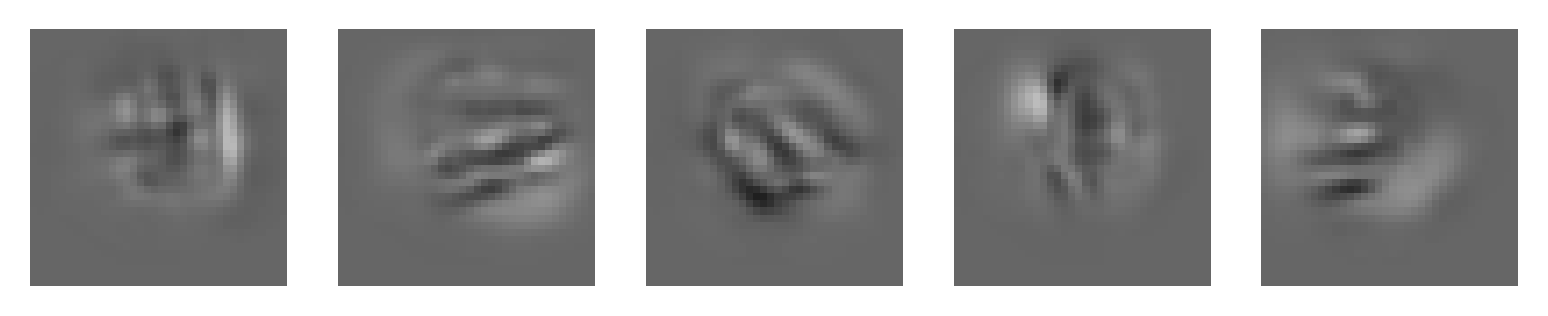

In [9]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

In [10]:
cossim.shape

(5, 5)

Text(0.5, 1.0, 'Cos sim between assigned Gs')

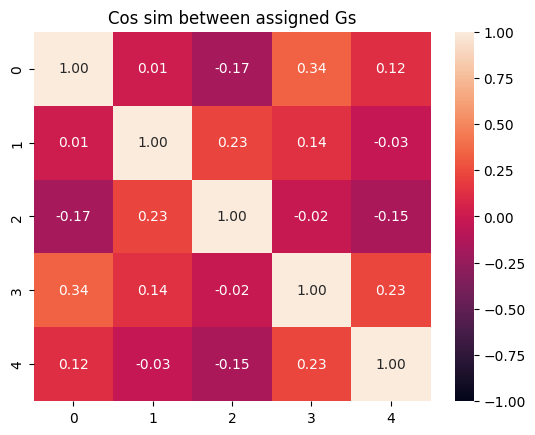

In [11]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

In [14]:
model.pattern_crops.shape

(9, 5, 144)

In [15]:
center_crops = model.pattern_crops[4]

In [16]:
center_crops.shape

(5, 144)

In [18]:
cossim_center_crops = cosine_similarity(center_crops)

Text(0.5, 1.0, 'Cos sim between center PFs')

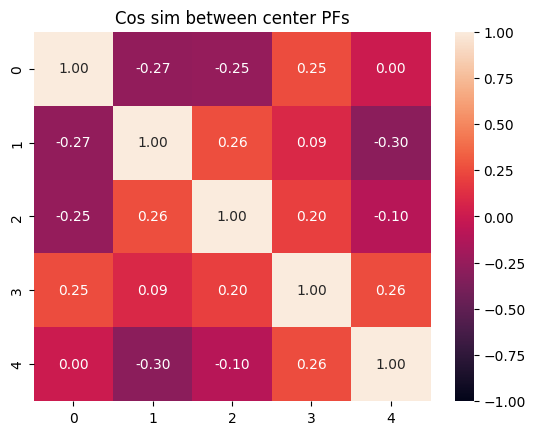

In [20]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim_center_crops, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between center PFs")

In [10]:
(
    MEIs,
    completing_patterns,
    disrupting_patterns_1,
    disrupting_patterns_2,
    disrupting_pattern_indices,
) = create_stimuli(patterns)

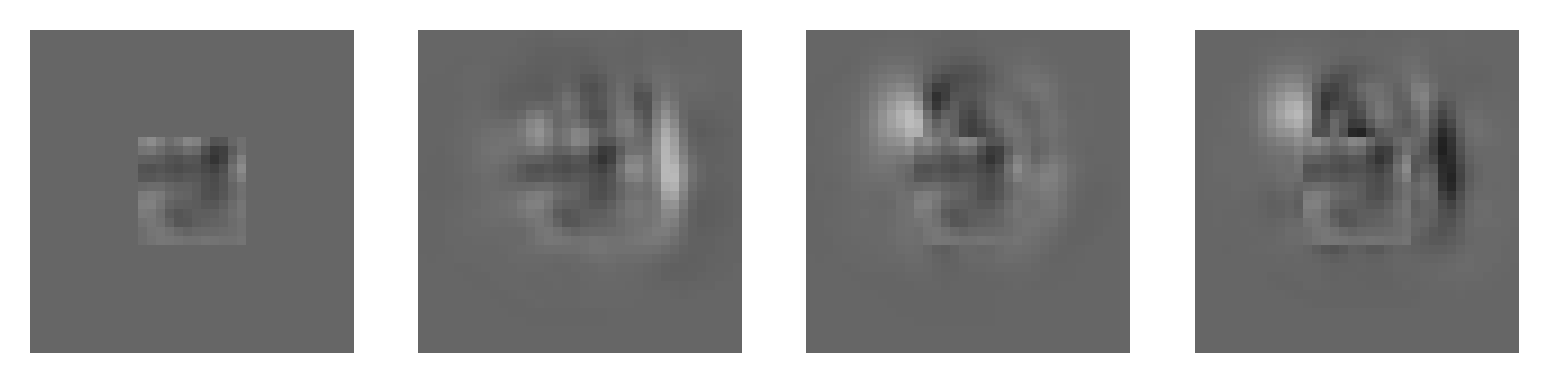

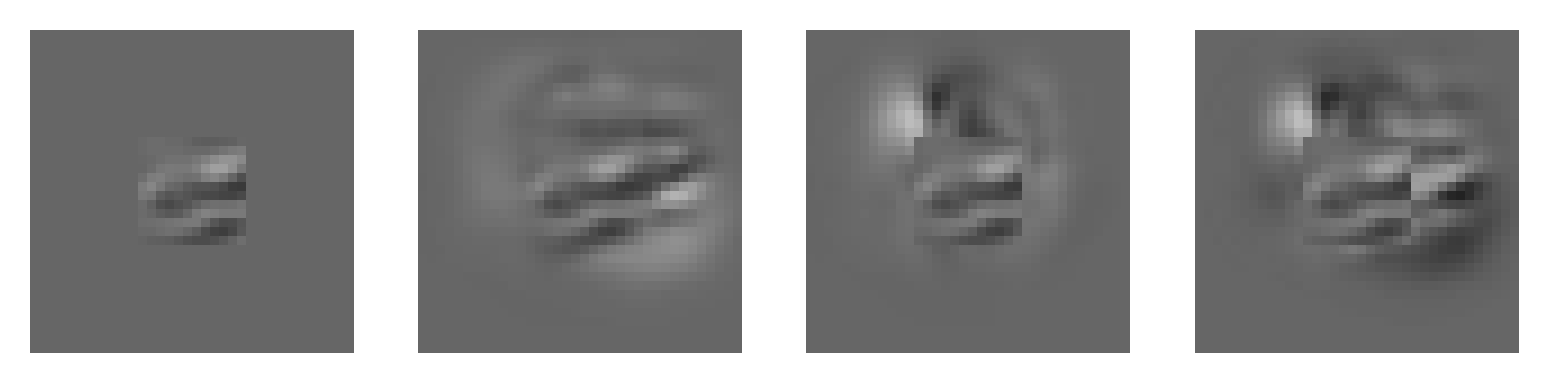

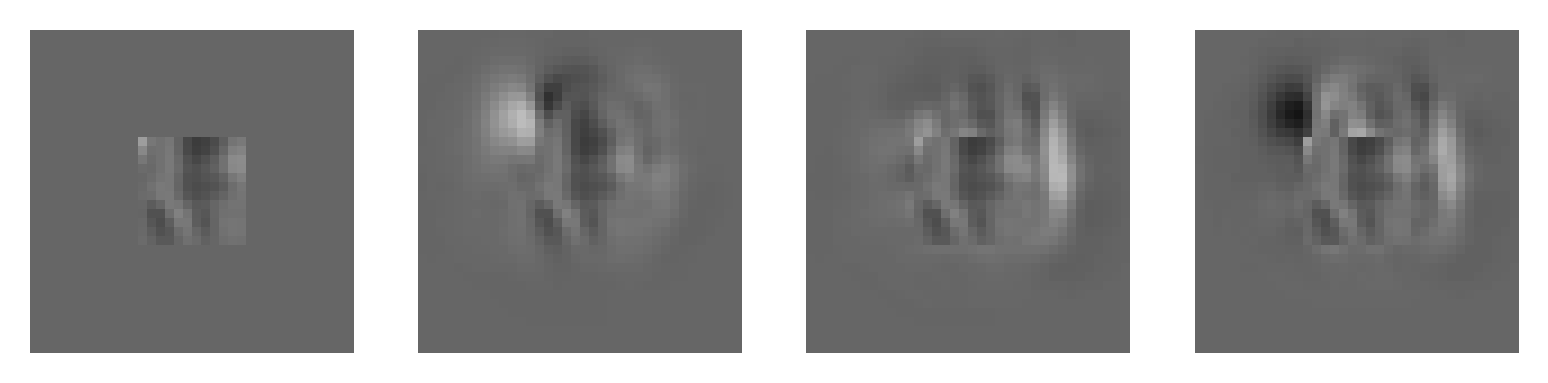

In [11]:
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(
    MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2
):
    fig, axs = plt.subplots(1, 4, dpi=300)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")

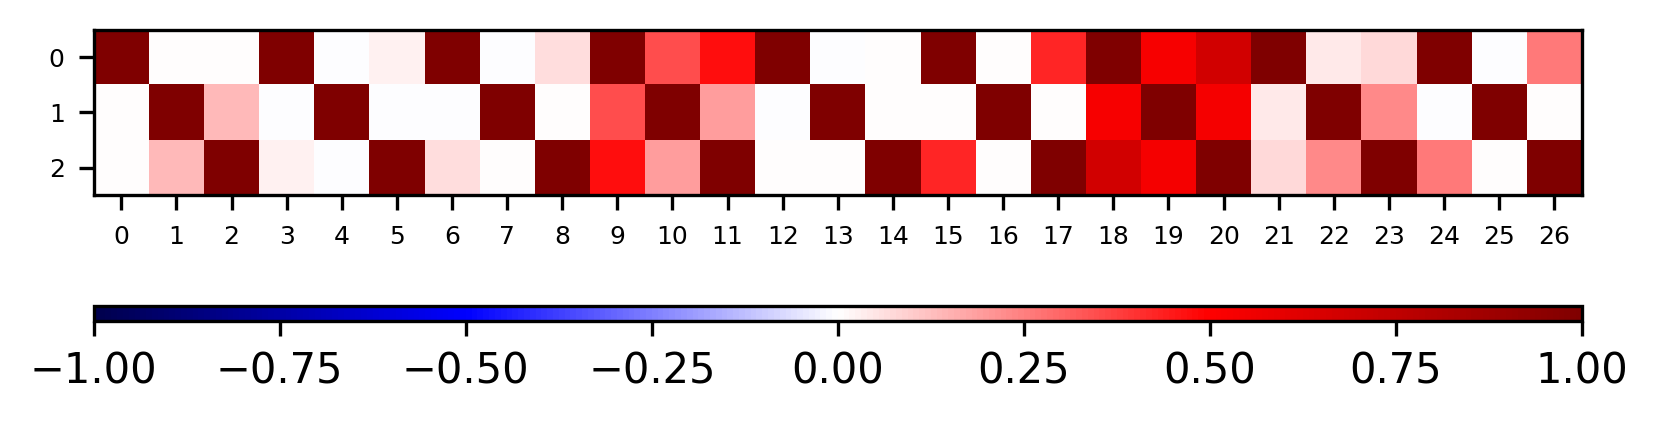

In [12]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim * 9))
ax.set_xticklabels(np.arange(G_dim * 9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis="both", which="major", labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(
    ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100
)

In [13]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(
    MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2
):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    all_idata.append(idata_set)

Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 18 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 20 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 19 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 17 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


...

Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 18 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 17 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 17 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 20 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 18 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


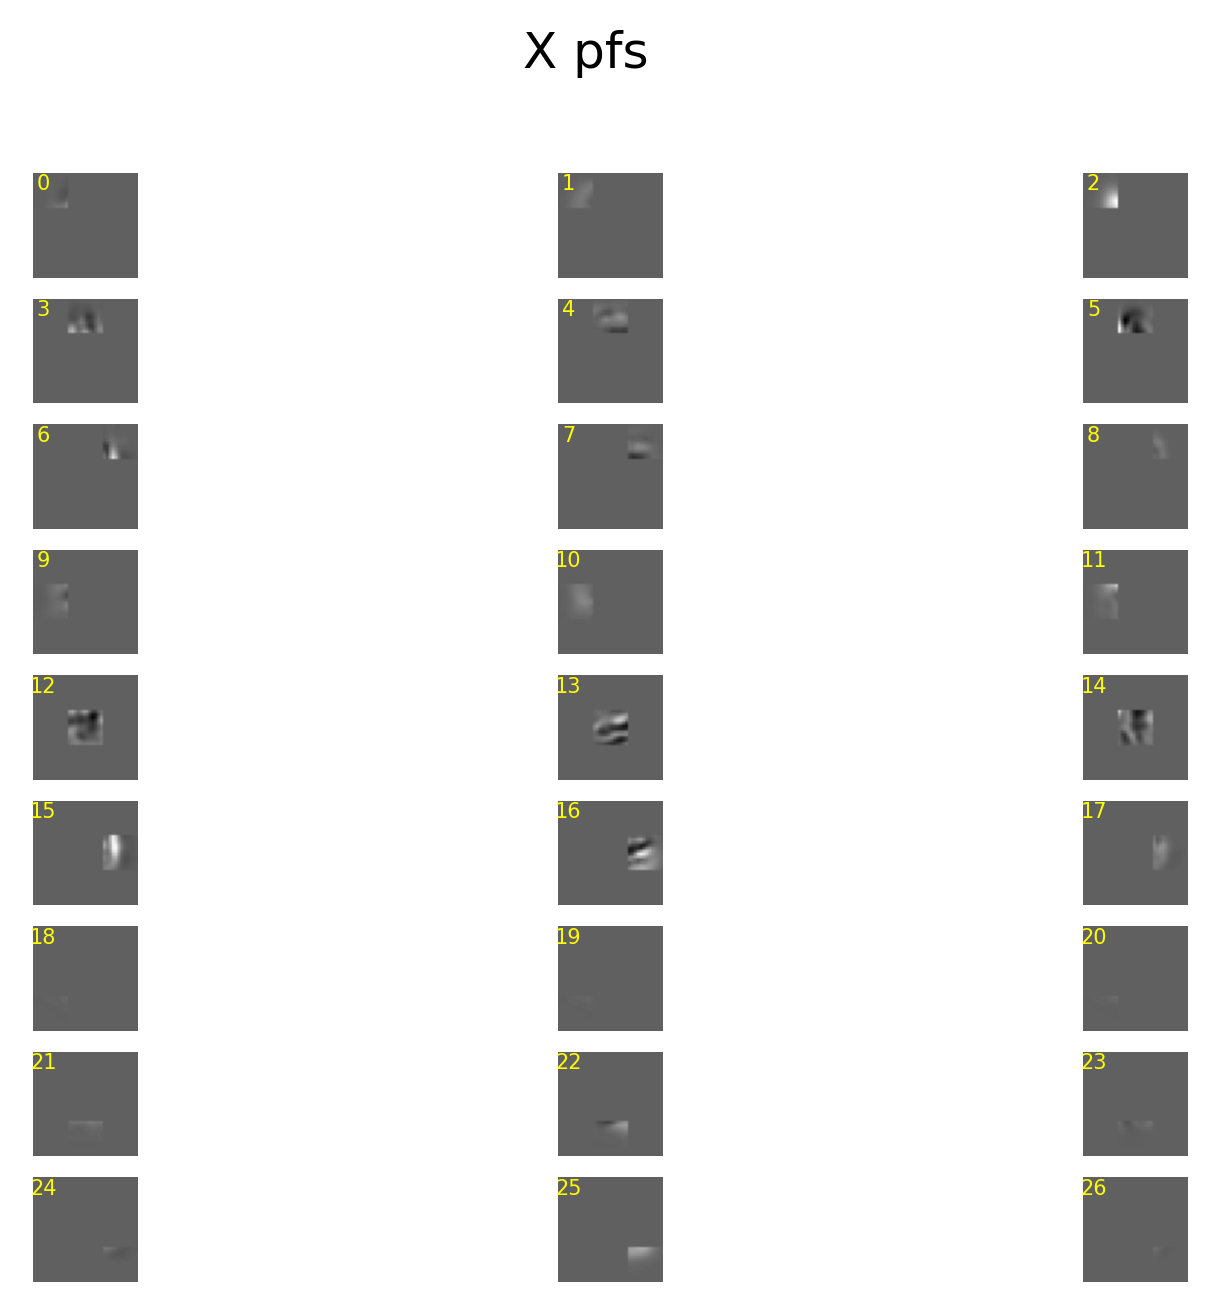

In [14]:
x_pfs = model.visualize_learned_X(9, 3)

In [15]:
disrupting_pattern_indices

[2, 2, 0]

[0, 1, 3, 4, 6, 7, 9, 10, 13, 14, 15, 16, 18, 19, 21, 22, 24, 25]
[0, 1, 3, 4, 6, 7, 9, 10, 12, 14, 15, 16, 18, 19, 21, 22, 24, 25]
[1, 2, 4, 5, 7, 8, 10, 11, 12, 13, 16, 17, 19, 20, 22, 23, 25, 26]


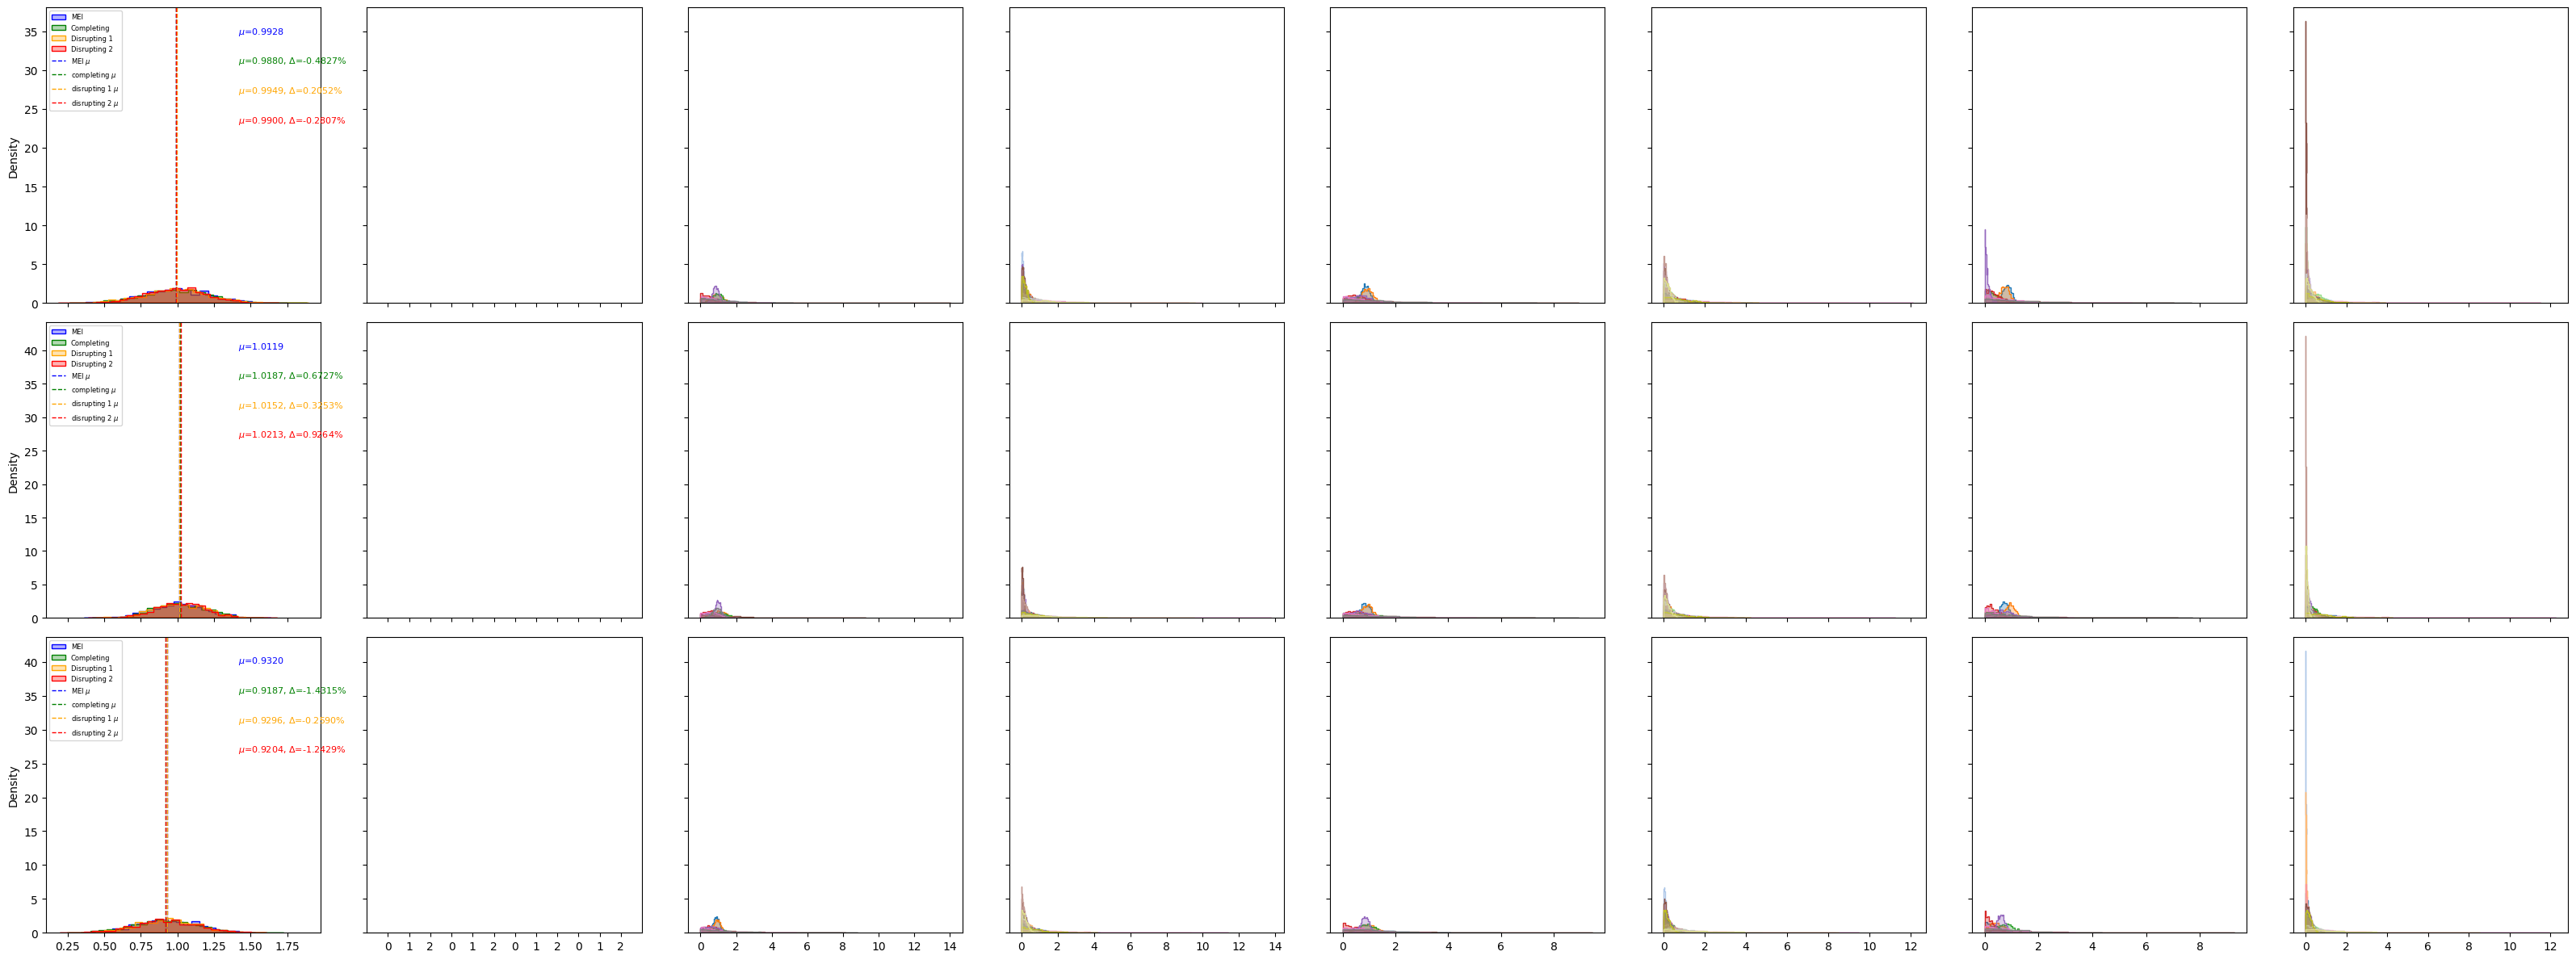

In [16]:
fig, axs = plt.subplots(
    G_dim, 8, figsize=(8 * 4, 3 * 4), tight_layout=True, sharex="col", sharey="row"
)
legend_size = 6
possible_center_x_ids = [4 * G_dim + i for i in range(G_dim)]
for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
    zip(axs, all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx
    # i for i in range(idx, G_dim)
    completing_surround_x_ids = [
        i for i in range(idx, 9 * G_dim, G_dim) if i != center_x_id
    ]
    # complement of completing_surround_x_ids
    not_completing_surround_x_ids = [
        i
        for i in range(9 * G_dim)
        if (i not in completing_surround_x_ids) and (i != center_x_id)
    ]
    disrupting_surround_x_ids = [
        i
        for i in range(disrupting_pattern_idx, 9 * G_dim, G_dim)
        if i not in possible_center_x_ids
    ]
    # complement of disrupting_surround_x_ids
    not_disrupting_surround_x_ids = [
        i
        for i in range(9 * G_dim)
        if (i not in disrupting_surround_x_ids) and (i != center_x_id)
    ]
    print(not_disrupting_surround_x_ids)

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_idata = idata_set[0]
    completing_idata = idata_set[1]
    disrupting_1_idata = idata_set[2]
    disrupting_2_idata = idata_set[3]

    mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    mei_x_mean = mei_x_samples.mean()
    sns.histplot(
        mei_x_samples,
        ax=ax_set[0],
        stat="density",
        color="blue",
        element="step",
        alpha=0.3,
        label="MEI",
    )

    # mei_idata["posterior"]["G"].data.shape = (n_chains, n_samples, n_G_dims)
    mei_g_samples = mei_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    # mei_g_samples.shape = (n_G_dims,)

    colors = plt.cm.tab10(range(len(completing_surround_x_ids)))
    for completing_surround_index, completing_surround_x_id in enumerate(
        completing_surround_x_ids
    ):
        completing_surround_x_samples = (
            completing_idata["posterior"]["X"]
            .data[:, :, completing_surround_x_id]
            .flatten()
        )
        sns.histplot(
            completing_surround_x_samples,
            ax=ax_set[2],
            stat="density",
            color=colors[completing_surround_index],
            element="step",
            alpha=0.3,
            label=f"{completing_surround_x_id}",
        )
        # ax_set[2].legend(prop={'size': legend_size}, loc="upper left")

    colors = plt.cm.tab20(range(len(not_completing_surround_x_ids)))
    for not_completing_surround_index, not_completing_surround_x_id in enumerate(
        not_completing_surround_x_ids
    ):
        not_completing_surround_x_samples = (
            completing_idata["posterior"]["X"]
            .data[:, :, not_completing_surround_x_id]
            .flatten()
        )
        sns.histplot(
            not_completing_surround_x_samples,
            ax=ax_set[3],
            stat="density",
            color=colors[not_completing_surround_index],
            element="step",
            alpha=0.3,
            label=f"{not_completing_surround_x_id}",
        )
        # ax_set[3].legend(prop={'size': legend_size}, loc="upper left")

    completing_x_samples = (
        completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    completing_x_mean = completing_x_samples.mean()
    completing_perc_diff = (completing_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        completing_x_samples,
        ax=ax_set[0],
        stat="density",
        color="green",
        element="step",
        alpha=0.3,
        label="Completing",
    )

    completing_g_samples = (
        completing_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    )

    disrupting_1_x_samples = (
        disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    disrupting_1_x_mean = disrupting_1_x_samples.mean()
    disrupting_1_perc_diff = (disrupting_1_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        disrupting_1_x_samples,
        ax=ax_set[0],
        stat="density",
        color="orange",
        element="step",
        alpha=0.3,
        label="Disrupting 1",
    )

    disrupting_1_g_samples = (
        disrupting_1_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    )

    disrupting_2_x_samples = (
        disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    disrupting_2_x_mean = disrupting_2_x_samples.mean()
    disrupting_2_perc_diff = (disrupting_2_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        disrupting_2_x_samples,
        ax=ax_set[0],
        stat="density",
        color="red",
        element="step",
        alpha=0.3,
        label="Disrupting 2",
    )

    disrupting_2_g_samples = (
        disrupting_2_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    )

    colors = plt.cm.tab10(range(len(disrupting_surround_x_ids)))
    for disrupting_surround_index, disrupting_surround_x_id in enumerate(
        disrupting_surround_x_ids
    ):
        disrupting_1_surround_x_samples = (
            disrupting_1_idata["posterior"]["X"]
            .data[:, :, disrupting_surround_x_id]
            .flatten()
        )
        sns.histplot(
            disrupting_1_surround_x_samples,
            ax=ax_set[4],
            stat="density",
            color=colors[disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{disrupting_surround_x_id}",
        )
        # ax_set[4].legend(prop={'size': legend_size}, loc="upper left")
        disrupting_2_surround_x_samples = (
            disrupting_2_idata["posterior"]["X"]
            .data[:, :, disrupting_surround_x_id]
            .flatten()
        )
        sns.histplot(
            disrupting_2_surround_x_samples,
            ax=ax_set[6],
            stat="density",
            color=colors[disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{disrupting_surround_x_id}",
        )
        # ax_set[6].legend(prop={'size': legend_size}, loc="upper left")

    colors = plt.cm.tab20(range(len(not_disrupting_surround_x_ids)))
    for not_disrupting_surround_index, not_disrupting_surround_x_id in enumerate(
        not_disrupting_surround_x_ids
    ):
        not_disrupting_1_surround_x_samples = (
            disrupting_1_idata["posterior"]["X"]
            .data[:, :, not_disrupting_surround_x_id]
            .flatten()
        )
        sns.histplot(
            not_disrupting_1_surround_x_samples,
            ax=ax_set[5],
            stat="density",
            color=colors[not_disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{not_disrupting_surround_x_id}",
        )
        # ax_set[5].legend(prop={'size': legend_size}, loc="upper left")
        not_disrupting_2_surround_x_samples = (
            disrupting_2_idata["posterior"]["X"]
            .data[:, :, not_disrupting_surround_x_id]
            .flatten()
        )
        sns.histplot(
            not_disrupting_2_surround_x_samples,
            ax=ax_set[7],
            stat="density",
            color=colors[not_disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{not_disrupting_surround_x_id}",
        )
        # ax_set[7].legend(prop={'size': legend_size}, loc="upper left")

    ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
    ax_set[1].bar(
        x=np.arange(G_dim) + G_dim,
        height=completing_g_samples,
        width=0.8,
        color="green",
    )
    ax_set[1].bar(
        x=np.arange(G_dim) + G_dim * 2,
        height=disrupting_1_g_samples,
        width=0.8,
        color="orange",
    )
    ax_set[1].bar(
        x=np.arange(G_dim) + G_dim * 3,
        height=disrupting_2_g_samples,
        width=0.8,
        color="red",
    )
    ax_set[1].set_xticks(np.arange(G_dim * 4))
    ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

    ax_set[0].text(
        0.7,
        0.9,
        f"$\mu$={mei_x_mean:.4f}",
        size=8,
        ha="left",
        va="bottom",
        transform=ax_set[0].transAxes,
        color="blue",
    )
    ax_set[0].text(
        0.7,
        0.8,
        f"$\mu$={completing_x_mean:.4f}, $\Delta$={completing_perc_diff:.4f}%",
        size=8,
        ha="left",
        va="bottom",
        transform=ax_set[0].transAxes,
        color="green",
    )
    ax_set[0].text(
        0.7,
        0.7,
        f"$\mu$={disrupting_1_x_mean:.4f}, $\Delta$={disrupting_1_perc_diff:.4f}%",
        size=8,
        ha="left",
        va="bottom",
        transform=ax_set[0].transAxes,
        color="orange",
    )
    ax_set[0].text(
        0.7,
        0.6,
        f"$\mu$={disrupting_2_x_mean:.4f}, $\Delta$={disrupting_2_perc_diff:.4f}%",
        size=8,
        ha="left",
        va="bottom",
        transform=ax_set[0].transAxes,
        color="red",
    )

    ax_set[0].axvline(
        mei_x_mean, color="blue", linestyle="--", linewidth=1, label="MEI $\mu$"
    )
    ax_set[0].axvline(
        completing_x_mean,
        color="green",
        linestyle="--",
        linewidth=1,
        label="completing $\mu$",
    )
    ax_set[0].axvline(
        disrupting_1_x_mean,
        color="orange",
        linestyle="--",
        linewidth=1,
        label="disrupting 1 $\mu$",
    )
    ax_set[0].axvline(
        disrupting_2_x_mean,
        color="red",
        linestyle="--",
        linewidth=1,
        label="disrupting 2 $\mu$",
    )
    ax_set[0].legend(prop={"size": legend_size}, loc="upper left")

In [17]:
mei_g_samples.shape

(3,)

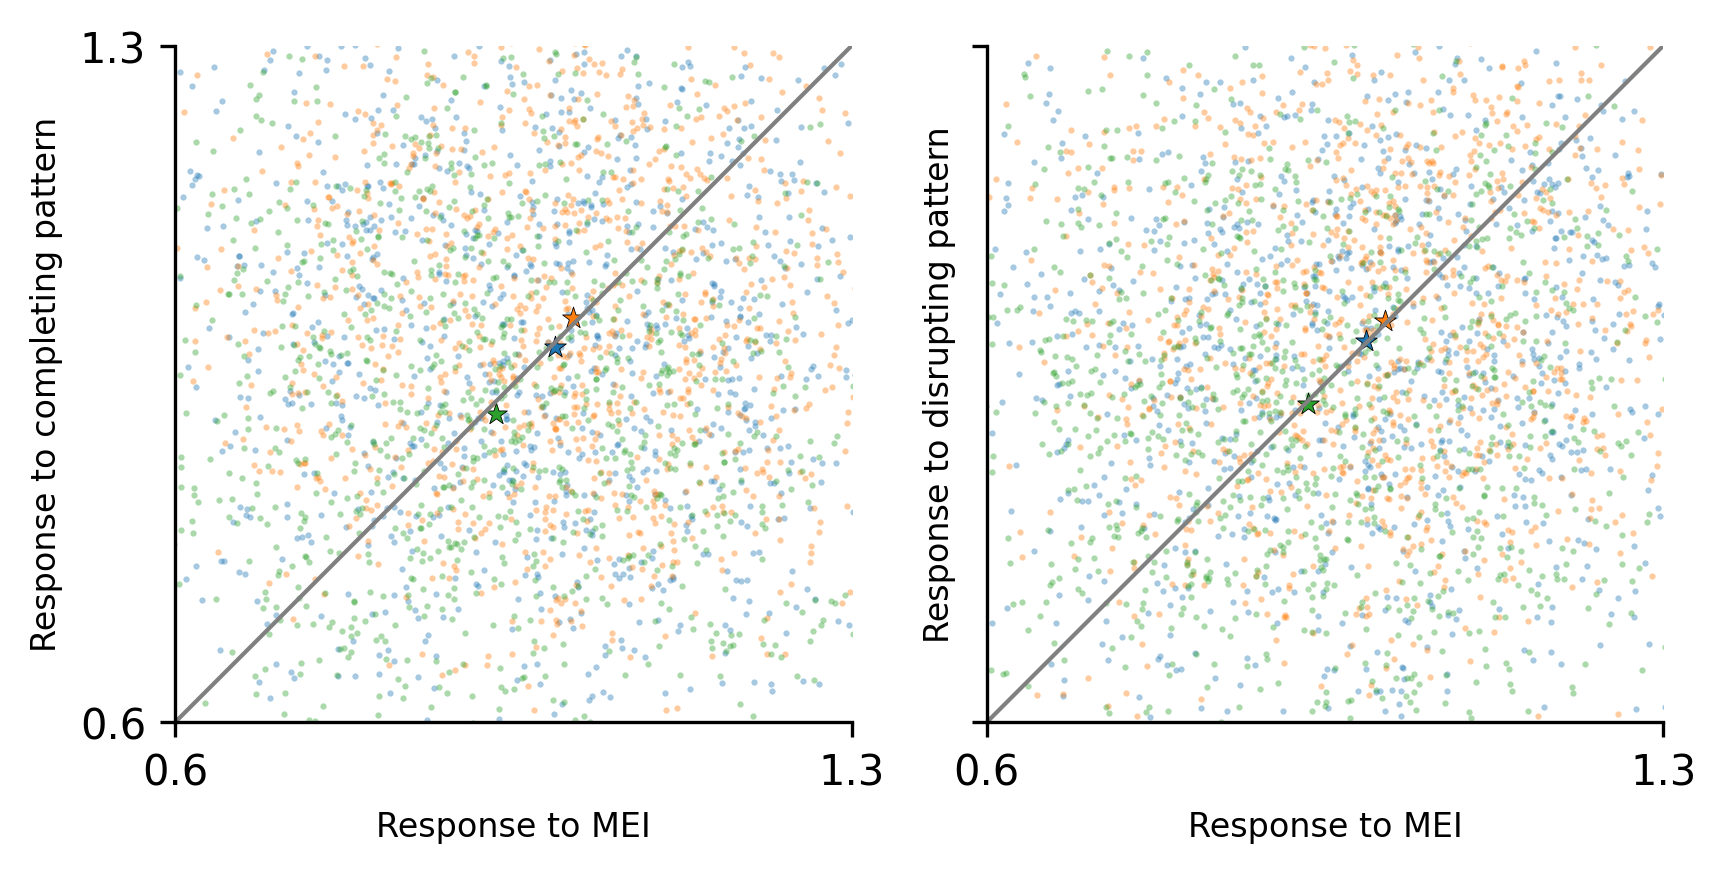

In [18]:
colors = plt.cm.tab10(range(len(all_idata)))
xlim = (0.6, 1.3)
xticks = [0.6, 1.3]
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=300, sharey=True)
for idx, (idata_set, disrupting_pattern_idx) in enumerate(
    zip(all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx
    # i for i in range(idx, G_dim)
    completing_surround_x_ids = [
        i for i in range(idx, 9 * G_dim, G_dim) if i != center_x_id
    ]
    # complement of completing_surround_x_ids
    disrupting_surround_x_ids = [
        i
        for i in range(disrupting_pattern_idx, 9 * G_dim, G_dim)
        if i not in possible_center_x_ids
    ]

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_idata = idata_set[0]
    completing_idata = idata_set[1]
    disrupting_1_idata = idata_set[2]
    disrupting_2_idata = idata_set[3]

    mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    mei_x_mean = mei_x_samples.mean()

    completing_x_samples = (
        completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    completing_x_mean = completing_x_samples.mean()

    axs[0].scatter(
        mei_x_samples,
        completing_x_samples,
        color=colors[idx],
        marker=".",
        s=1,
        alpha=0.4,
    )

    disrupting_1_x_samples = (
        disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    disrupting_1_x_mean = disrupting_1_x_samples.mean()

    disrupting_2_x_samples = (
        disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    disrupting_2_x_mean = disrupting_2_x_samples.mean()
    axs[1].scatter(
        mei_x_samples,
        disrupting_1_x_samples,
        color=colors[idx],
        marker=".",
        s=1,
        alpha=0.4,
    )
    # axs[2].scatter(
    #     mei_x_samples,
    #     disrupting_2_x_samples,
    #     color=colors[idx],
    #     marker=".",
    #     s=1,
    #     alpha=0.4,
    # )

for ax in axs:
    # draw a diagonal line
    ax.plot(
        xlim,
        xlim,
        color="gray",
        # linestyle="dashed",
        linewidth=1,
    )
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_ylim(xlim)
    ax.set_yticks(xticks)
    ax.set_aspect("equal", adjustable="box")
    sns.despine(ax=ax, trim=True)
    # break

for idx, (idata_set, disrupting_pattern_idx) in enumerate(
    zip(all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx
    # i for i in range(idx, G_dim)
    completing_surround_x_ids = [
        i for i in range(idx, 9 * G_dim, G_dim) if i != center_x_id
    ]
    # complement of completing_surround_x_ids
    disrupting_surround_x_ids = [
        i
        for i in range(disrupting_pattern_idx, 9 * G_dim, G_dim)
        if i not in possible_center_x_ids
    ]

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_idata = idata_set[0]
    completing_idata = idata_set[1]
    disrupting_1_idata = idata_set[2]
    disrupting_2_idata = idata_set[3]

    mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    mei_x_mean = mei_x_samples.mean()

    completing_x_samples = (
        completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    completing_x_mean = completing_x_samples.mean()

    axs[0].scatter(
        mei_x_mean,
        completing_x_mean,
        color=colors[idx],
        marker="*",
        s=30,
        alpha=1,
        edgecolor="black",
        linewidth=0.2,
    )
    axs[0].set_xlabel("Response to MEI", fontsize=8)

    disrupting_1_x_samples = (
        disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    disrupting_1_x_mean = disrupting_1_x_samples.mean()

    axs[1].scatter(
        mei_x_mean,
        disrupting_1_x_mean,
        color=colors[idx],
        marker="*",
        s=30,
        alpha=1,
        edgecolor="black",
        linewidth=0.2,
    )
    axs[1].set_xlabel("Response to MEI", fontsize=8)

    axs[0].set_ylabel("Response to completing pattern", fontsize=8)
    axs[1].set_ylabel("Response to disrupting pattern", fontsize=8)

    disrupting_2_x_samples = (
        disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    )
    disrupting_2_x_mean = disrupting_2_x_samples.mean()
    # axs[2].scatter(
    #     mei_x_mean,
    #     disrupting_1_x_mean,
    #     color=colors[idx],
    #     marker="*",
    #     s=30,
    #     alpha=1,
    #     edgecolor="black",
    #     linewidth=0.2,
    # )
    # break